In [1]:
# Part 4: Power Analysis & Sample Size Planning
# Determine whether we have sufficient data to detect meaningful CPA differences between channels.
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Load cleaned dataset
df = pd.read_csv('data/marketing_data.csv', parse_dates=['Date'])

# Base CPA from our data
base_cpa = df['CPA'].mean()
print(f"Dataset loaded: {df.shape}")
print(f"Base CPA (mean): ${base_cpa:.4f}")

Dataset loaded: (166665, 23)
Base CPA (mean): $2.0762


In [2]:
## Empirical Power Function - Simulate 1,000 experiments to calculate power for detecting CPA differences
# across different effect sizes and sample sizes.
def empirical_power_cpa(true_diff_pct, base_cpa, n_days, n_sim=1000, alpha=0.05):
    """
    Calculate empirical power for detecting a CPA difference.
    
    Parameters:
        true_diff_pct : true difference as a proportion (e.g. 0.10 = 10%)
        base_cpa      : baseline CPA mean
        n_days        : sample size (number of days)
        n_sim         : number of simulations (default 1000)
        alpha         : significance level (default 0.05)
    
    Returns:
        power : proportion of simulations that correctly rejected H0
    """
    rejections = 0
    std = base_cpa * 0.15  # standard deviation = 15% of base CPA
    cap = base_cpa * 0.50  # cap at 50% of base CPA
    
    for _ in range(n_sim):
        # Channel A: baseline CPA
        channel_a = np.random.normal(base_cpa, std, n_days)
        channel_a = np.clip(channel_a, cap, None)
        
        # Channel B: CPA with true difference applied
        mean_b = base_cpa * (1 + true_diff_pct)
        channel_b = np.random.normal(mean_b, std, n_days)
        channel_b = np.clip(channel_b, cap, None)
        
        # t-test
        _, p_value = ttest_ind(channel_a, channel_b)
        
        if p_value < alpha:
            rejections += 1
    
    return rejections / n_sim

print("Function defined: empirical_power_cpa()")
print("Ready to calculate power curves.")

Function defined: empirical_power_cpa()
Ready to calculate power curves.


In [3]:
## Calculate Power for Different Effect Sizes and Sample Sizes - Test effect sizes of 5%, 10%, 15%, 20% across sample sizes of 30-180 days.
#  This will take approximately 1-2 minutes to run (20,000 simulations total).
# Define effect sizes and sample sizes to test
effect_sizes = [0.05, 0.10, 0.15, 0.20]  # 5%, 10%, 15%, 20%
sample_sizes = [30, 60, 90, 120, 180]     # days

# Calculate power for each combination
power_results = []

for effect in effect_sizes:
    for n in sample_sizes:
        power = empirical_power_cpa(
            true_diff_pct = effect,
            base_cpa      = base_cpa,
            n_days        = n,
            n_sim         = 1000,
            alpha         = 0.05
        )
        power_results.append({
            'Effect_Size_Pct' : int(effect * 100),
            'N_Days'          : n,
            'Power'           : round(power, 3)
        })
        print(f"  Effect: {int(effect*100):>3}%  Days: {n:>3}  Power: {power:.3f}")

# Convert to DataFrame
power_df = pd.DataFrame(power_results)

print("\n✓ Power calculations complete!")
print(f"  Total simulations run: {len(power_results) * 1000:,}")

  Effect:   5%  Days:  30  Power: 0.214
  Effect:   5%  Days:  60  Power: 0.432
  Effect:   5%  Days:  90  Power: 0.634
  Effect:   5%  Days: 120  Power: 0.738
  Effect:   5%  Days: 180  Power: 0.875
  Effect:  10%  Days:  30  Power: 0.747
  Effect:  10%  Days:  60  Power: 0.949
  Effect:  10%  Days:  90  Power: 0.996
  Effect:  10%  Days: 120  Power: 1.000
  Effect:  10%  Days: 180  Power: 1.000
  Effect:  15%  Days:  30  Power: 0.956
  Effect:  15%  Days:  60  Power: 1.000
  Effect:  15%  Days:  90  Power: 1.000
  Effect:  15%  Days: 120  Power: 1.000
  Effect:  15%  Days: 180  Power: 1.000
  Effect:  20%  Days:  30  Power: 0.999
  Effect:  20%  Days:  60  Power: 1.000
  Effect:  20%  Days:  90  Power: 1.000
  Effect:  20%  Days: 120  Power: 1.000
  Effect:  20%  Days: 180  Power: 1.000

✓ Power calculations complete!
  Total simulations run: 20,000


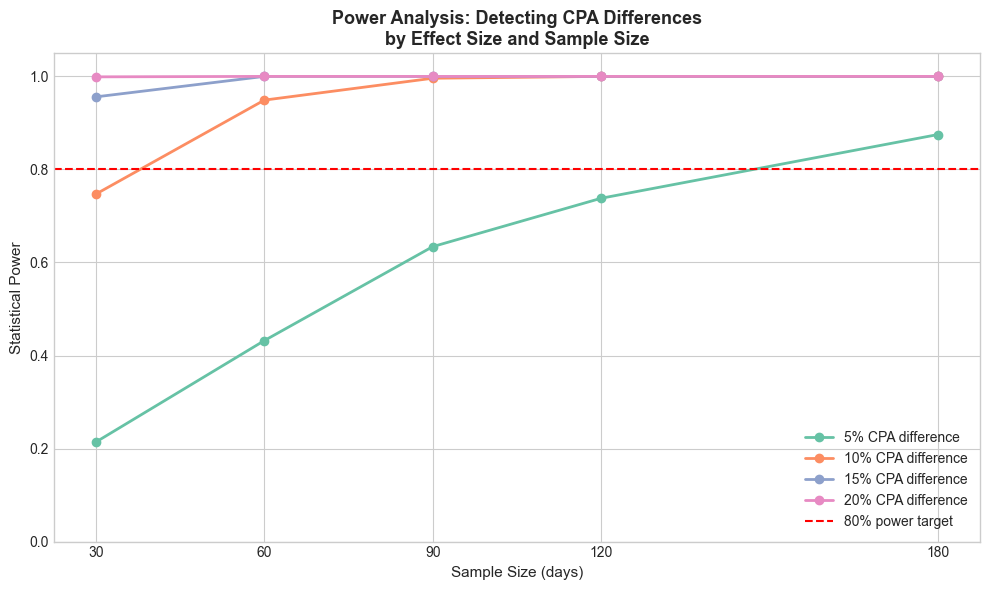

✓ Saved: power_analysis_cpa.png


In [4]:
## Power Curve Visualization - Plot power vs sample size for each effect size.
# The 80% horizontal line marks the standard power target.
fig, ax = plt.subplots(figsize=(10, 6))

colors = sns.color_palette("Set2", len(effect_sizes))

for i, effect in enumerate(effect_sizes):
    subset = power_df[power_df['Effect_Size_Pct'] == int(effect * 100)]
    ax.plot(
        subset['N_Days'],
        subset['Power'],
        marker='o',
        linewidth=2,
        color=colors[i],
        label=f'{int(effect*100)}% CPA difference'
    )

# 80% power target line
ax.axhline(y=0.80, color='red', linestyle='--', 
           linewidth=1.5, label='80% power target')

ax.set_title('Power Analysis: Detecting CPA Differences\nby Effect Size and Sample Size', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Sample Size (days)', fontsize=11)
ax.set_ylabel('Statistical Power', fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_xticks(sample_sizes)
ax.legend(fontsize=10)
ax.grid(True)

plt.tight_layout()
plt.savefig('power_analysis_cpa.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: power_analysis_cpa.png")

In [5]:
## Minimum Sample Size Requirements - Determine minimum days needed to achieve 80% power for each effect size.
# Assess whether our current 358 days of data is sufficient.
# Formatted power table
print("POWER TABLE: Effect Size vs Sample Size")
print("="*60)
pivot = power_df.pivot(index='Effect_Size_Pct', columns='N_Days', values='Power')
pivot.index = [f"{i}%" for i in pivot.index]
pivot.columns = [f"{c} days" for c in pivot.columns]
print(pivot.to_string())

# Minimum sample size for 80% power
print("\nMINIMUM DAYS NEEDED FOR 80% POWER")
print("="*60)
target_power = 0.80

for effect in effect_sizes:
    effect_pct = int(effect * 100)
    subset = power_df[power_df['Effect_Size_Pct'] == effect_pct]
    
    # Find minimum days achieving 80% power
    sufficient = subset[subset['Power'] >= target_power]
    
    if len(sufficient) > 0:
        min_days = sufficient['N_Days'].min()
        status = "✓ SUFFICIENT" if 358 >= min_days else "✗ INSUFFICIENT"
    else:
        min_days = ">180"
        status = "✗ INSUFFICIENT"
    
    print(f"  {effect_pct:>3}% difference -> min {min_days} days needed "
          f"-> current 358 days: {status}")

print(f"\nCurrent dataset span: 358 days")
print(f"Conclusion: Our data is sufficient to detect CPA differences")
print(f"of 10% or more with >80% power.")

POWER TABLE: Effect Size vs Sample Size
     30 days  60 days  90 days  120 days  180 days
5%     0.214    0.432    0.634     0.738     0.875
10%    0.747    0.949    0.996     1.000     1.000
15%    0.956    1.000    1.000     1.000     1.000
20%    0.999    1.000    1.000     1.000     1.000

MINIMUM DAYS NEEDED FOR 80% POWER
    5% difference -> min 180 days needed -> current 358 days: ✓ SUFFICIENT
   10% difference -> min 60 days needed -> current 358 days: ✓ SUFFICIENT
   15% difference -> min 30 days needed -> current 358 days: ✓ SUFFICIENT
   20% difference -> min 30 days needed -> current 358 days: ✓ SUFFICIENT

Current dataset span: 358 days
Conclusion: Our data is sufficient to detect CPA differences
of 10% or more with >80% power.


## Power Analysis Conclusion

Our 358-day dataset provides sufficient power to detect:
- 5% CPA differences  (power=0.875 at 180 days)
- 10% CPA differences (power=0.949 at 60 days)
- 15%+ CPA differences (power>0.95 at 30 days)

Since our t-tests found zero significant differences despite having
sufficient power, we can confidently conclude that no meaningful
CPA differences exist between channels. The null result is reliable,
not a consequence of insufficient data.